In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks',
    '/home/export/soheuny/SRFinder/soheun/notebooks/draft'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("/home/export/soheuny/SRFinder/soheun")

In [2]:
from typing import Tuple, Any
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut
from events_data import events_from_scdinfo
from dataset import MotherSamples
from training_info import TrainingInfo
from events_data import EventsData

SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3
# legend font size
plt.rcParams["legend.fontsize"] = 15

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}


def get_events_tst(smeared_hash: str) -> EventsData:
    smeared_fvt_tinfo = TrainingInfo.load(smeared_hash)
        
    base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    ms_hash = base_fvt_tinfo.ms_hash
    ms_idx = base_fvt_tinfo.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data(loaded_df)
    events_tst = EventsData.from_dataframe(df_tst, features)
    return events_tst


smeared_fvt_training_ensemble


  0%|          | 0/1 [00:00<?, ?it/s]

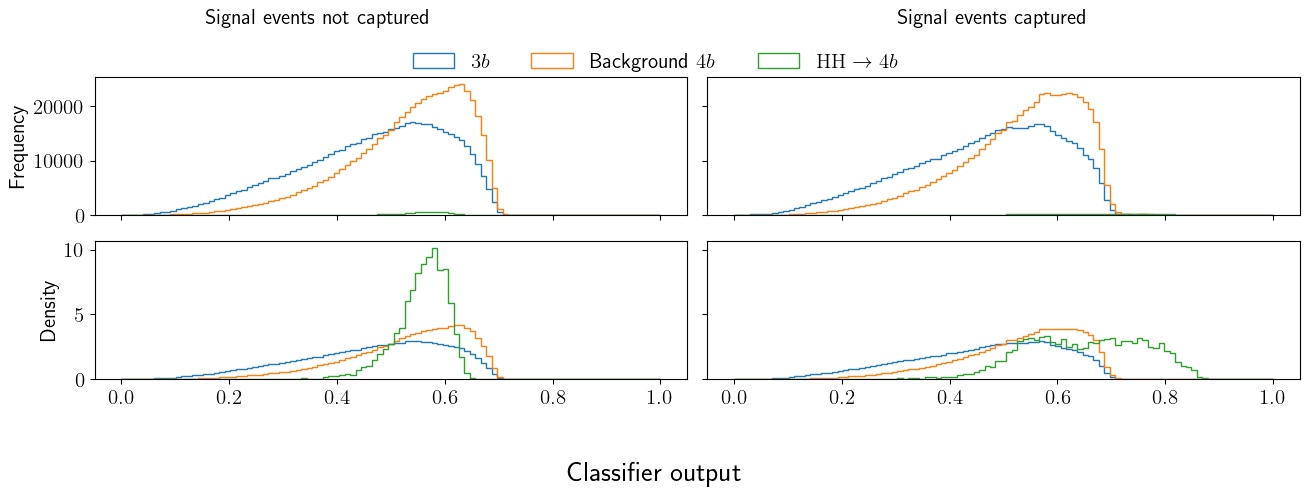

100%|██████████| 1/1 [00:01<00:00,  1.42s/it]


In [10]:
from plots import hist_events_by_labels
import tqdm

n_3b = 100_0000
seeds = range(1)
signal_ratio = 0.01
ensemble_seed = 0
noise_scale = 1.0

for experiment_name in [
    "smeared_fvt_training_ensemble",
    # "smeared_fvt_training_ensemble_HH4b_400",
    # "smeared_fvt_training_ensemble_HH4b_800"
    ]:

    w_4b_ratio_points = np.arange(0, 1.01, 0.01)
    signal_in_sr_list_dict = {"max_fvt": [], "mean_fvt": []}
    
    print(experiment_name)
    for seed in tqdm.tqdm(seeds):
        hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            "smearing": lambda x: x["noise_scale"] == noise_scale
                                            }, return_hparams=True, use_cached_metadata=True)
        
        failed_seed = 0
        success_seed = 11
        
        fig, ax = plt.subplots(2, 2, figsize=(15, 5), sharex=True, sharey="row")
        
        for i, seed in enumerate([failed_seed, success_seed]):
            hash_ = hashes[seed]
            smeared_fvt_tinfo = TrainingInfo.load(hash_)
            base_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
            base_fvt_tinfo = TrainingInfo.load(base_hash)
            base_fvt_logit = base_fvt_tinfo.aux_info["base_fvt_logit_tst"]
            base_fvt_score = np.exp(base_fvt_logit) / (1 + np.exp(base_fvt_logit))
            events_tst = get_events_tst(hash_)
            labels = {"3b": r"$3b$", "bg4b": rf"Background $4b$", "signal": r"$\mathrm{HH} \to 4b$"}
            hist_events_by_labels(events_tst, base_fvt_score, bins=np.linspace(0, 1, 100), ax=ax[0, i], 
                                  density=False, labels=labels)
            hist_events_by_labels(events_tst, base_fvt_score, bins=np.linspace(0, 1, 100), ax=ax[1, i], 
                                  density=True, labels=labels)
        
        for a in ax.flatten():
            a.legend(loc="upper left")
        fig.supxlabel("Classifier output")
        ax[0, 0].set_ylabel("Frequency")
        ax[1, 0].set_ylabel("Density")
        # ax[0, 0].set_title("Signal events not captured")
        # ax[0, 1].set_title("Signal events captured")

        fig.text(0.275, 0.965, "Signal events not captured", ha="center", va="top", fontsize=15)
        fig.text(0.725, 0.965, "Signal events captured",     ha="center", va="top", fontsize=15)

        # Shared legend just below the headers
        h, l = ax[0, 0].get_legend_handles_labels()
        fig.legend(h, l,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.915),  # (x,y) relative position in figure coords
           ncol=3,
           frameon=False)
        
        # Remove per-axes legends
        for a in ax.ravel():
            leg = a.get_legend()
            if leg is not None:
                leg.remove()

        plt.tight_layout(rect=[0.06, 0.06, 0.94, 0.86])
        plt.savefig(f"./figures/classifier_example_hist_exp={experiment_name}_signal={signal_ratio}.pdf", dpi=200)
        plt.show()
        plt.close()

smeared_fvt_training_ensemble


  0%|          | 0/1 [00:00<?, ?it/s]

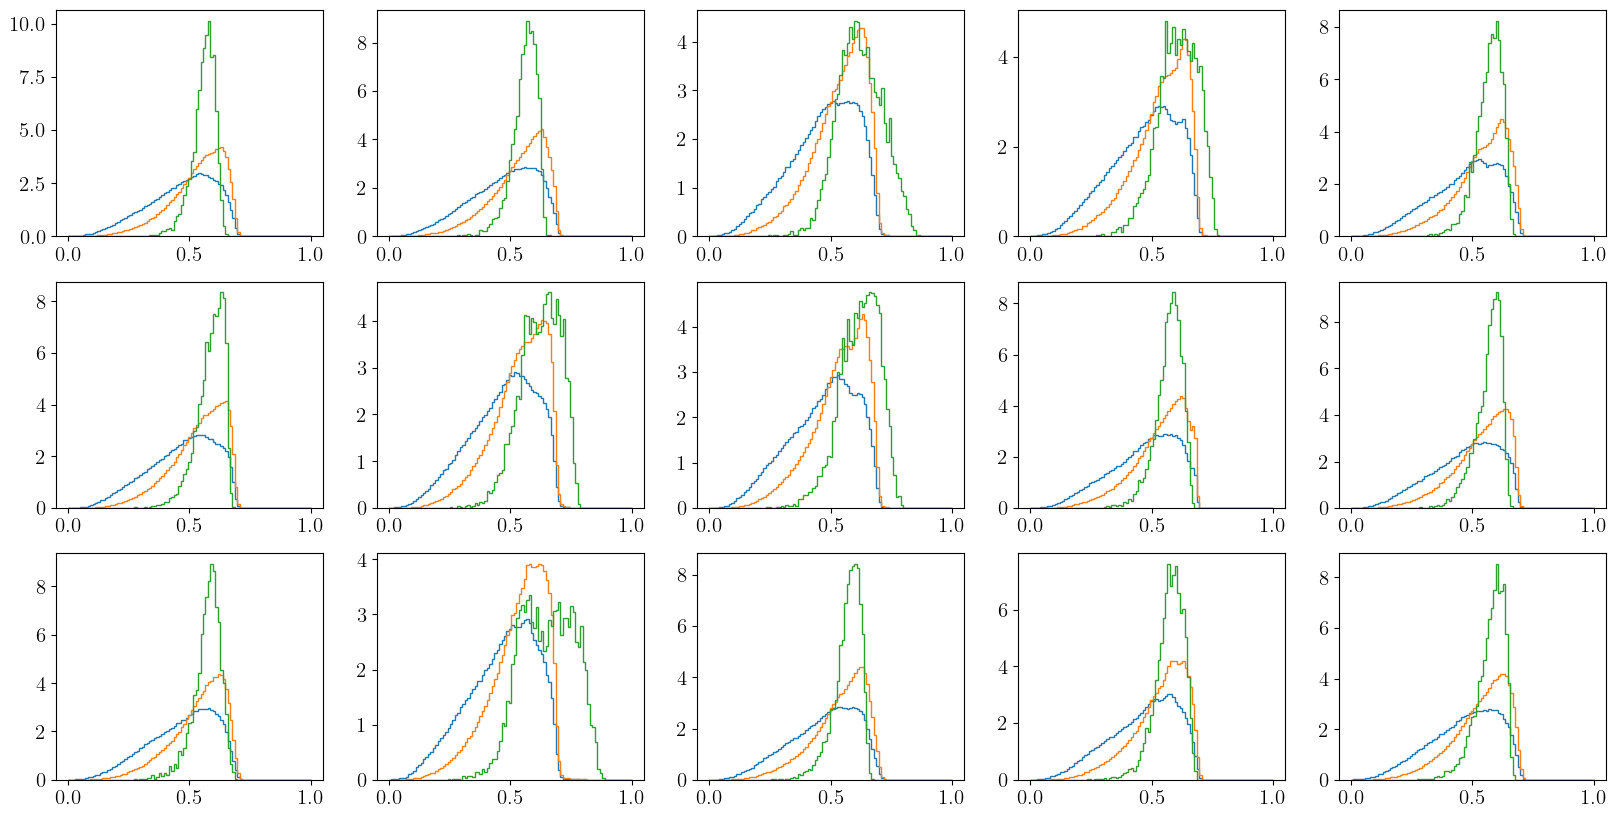

100%|██████████| 1/1 [00:08<00:00,  8.30s/it]


smeared_fvt_training_ensemble_HH4b_400


  0%|          | 0/1 [00:00<?, ?it/s]

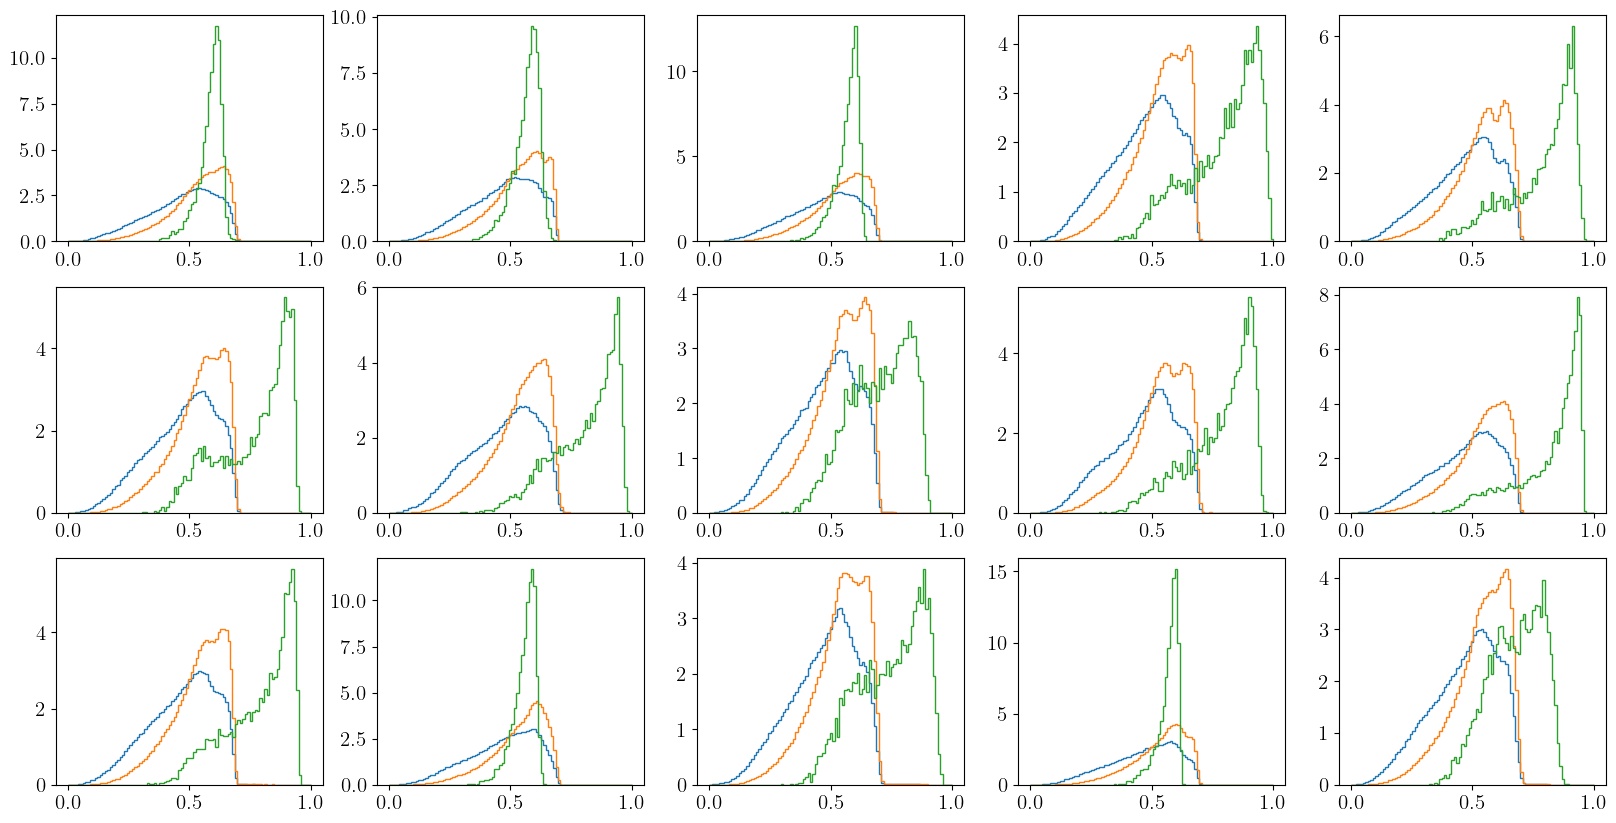

100%|██████████| 1/1 [00:06<00:00,  6.27s/it]


smeared_fvt_training_ensemble_HH4b_800


  0%|          | 0/1 [00:00<?, ?it/s]

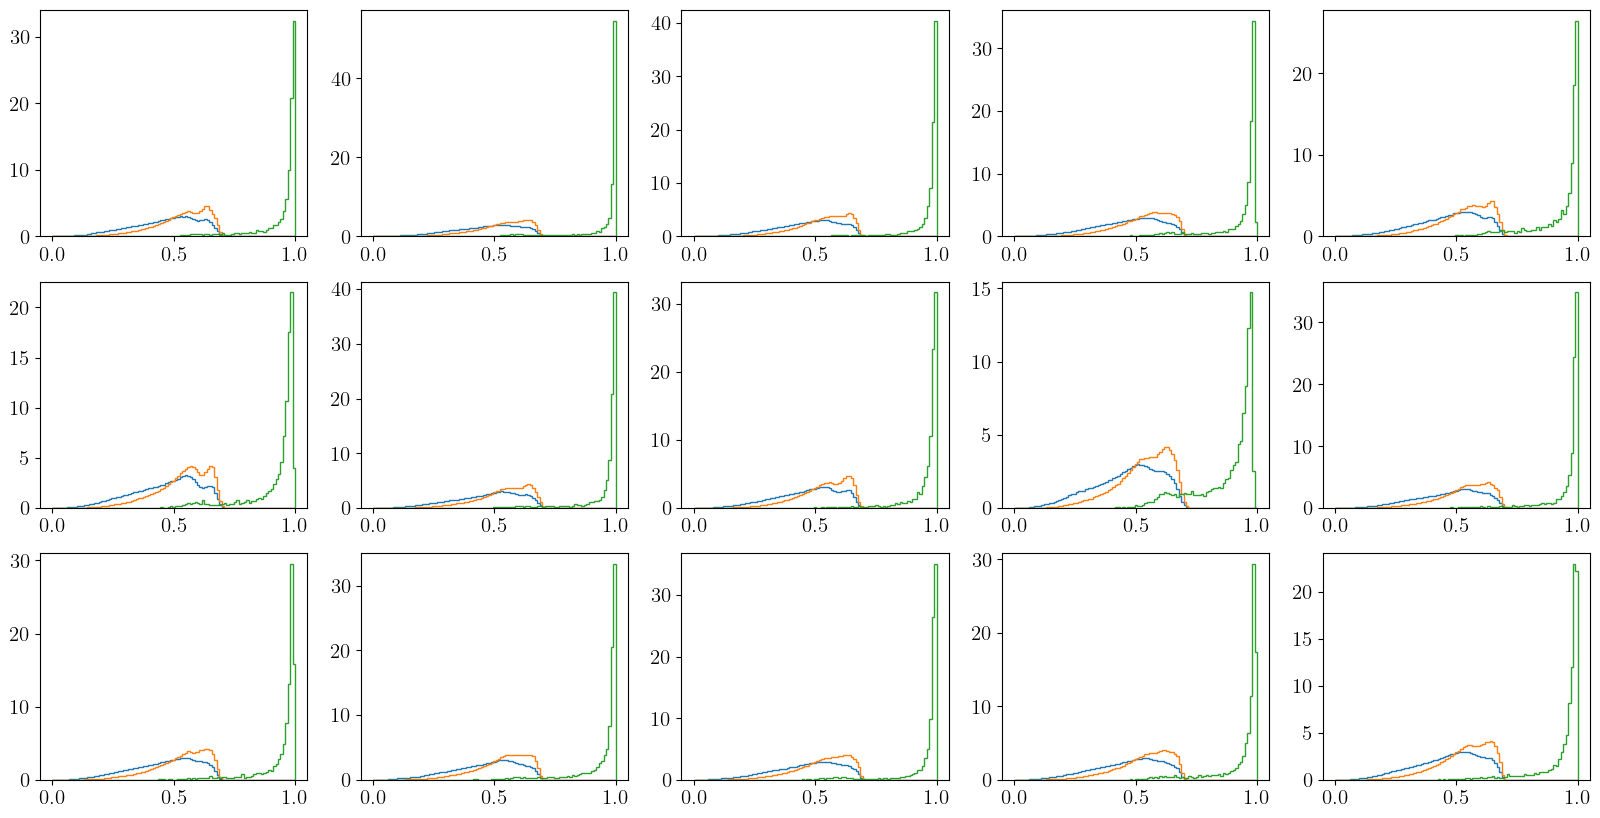

100%|██████████| 1/1 [00:07<00:00,  7.90s/it]


In [24]:
from plots import hist_events_by_labels
import tqdm

n_3b = 100_0000
seeds = range(1)
signal_ratio = 0.01
ensemble_seed = 0
noise_scale = 1.0

for experiment_name in [
    "smeared_fvt_training_ensemble",
    "smeared_fvt_training_ensemble_HH4b_400",
    "smeared_fvt_training_ensemble_HH4b_800"]:

    w_4b_ratio_points = np.arange(0, 1.01, 0.01)
    signal_in_sr_list_dict = {"max_fvt": [], "mean_fvt": []}
    
    print(experiment_name)
    for seed in tqdm.tqdm(seeds):
        hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            "smearing": lambda x: x["noise_scale"] == noise_scale
                                            }, return_hparams=True, use_cached_metadata=True)
        
        n_cols = 3
        n_rows = 5
        fig, ax = plt.subplots(n_cols, n_rows, figsize=(20, 10))
        
        for i in range(15):
            current_ax = ax[i // n_rows, i % n_rows]
            hash_ = hashes[i]
            smeared_fvt_tinfo = TrainingInfo.load(hash_)
            base_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
            base_fvt_tinfo = TrainingInfo.load(base_hash)
            base_fvt_logit = base_fvt_tinfo.aux_info["base_fvt_logit_tst"]
            base_fvt_score = np.exp(base_fvt_logit) / (1 + np.exp(base_fvt_logit))
            events_tst = get_events_tst(hash_)
            hist_events_by_labels(events_tst, base_fvt_score, bins=np.linspace(0, 1, 100), ax=current_ax, 
                                  density=True)
        
        plt.show()